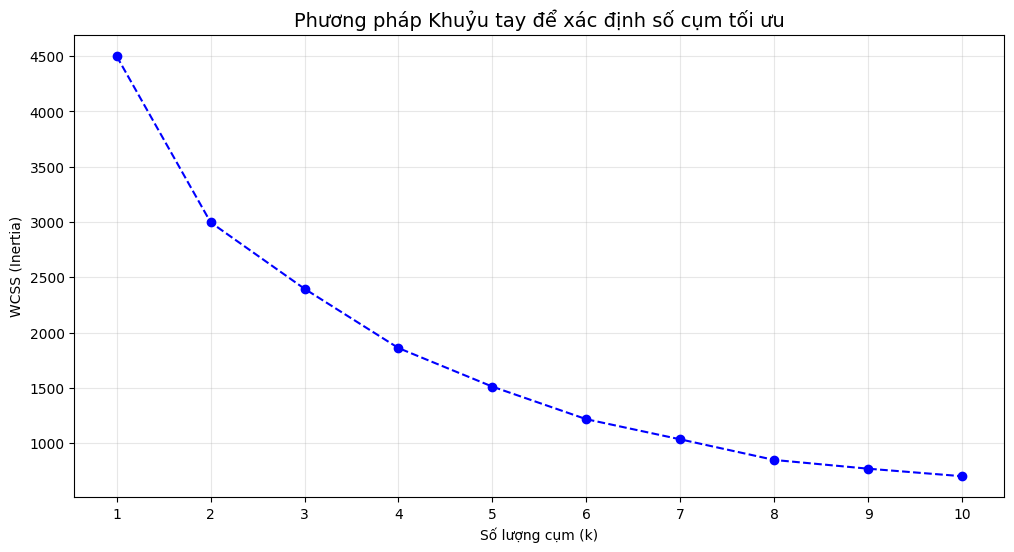

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Kết nối Database và lấy dữ liệu
engine = create_engine("mysql+pymysql://root:@127.0.0.1/ocd_analysis")
df = pd.read_sql("SELECT * FROM ocd_patient_dataset", engine)

# 2. Tiền xử lý dữ liệu (Feature Engineering)
# Chuyển đổi Family History thành số (Yes=1, No=0) để máy hiểu được
df['Family_History_Bin'] = df['Family History of OCD'].map({'Yes': 1, 'No': 0})
df['Total_Score'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

# Chọn các đặc điểm để phân cụm
# Chúng ta dùng Age, Total_Score và Family History để tìm các "kiểu hình" bệnh nhân
X = df[['Age', 'Total_Score', 'Family_History_Bin']]

# 3. Chuẩn hóa dữ liệu (Scaling) - Cực kỳ quan trọng cho K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Triển khai Phương pháp Khuỷu tay (Elbow Method)
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ chính là WCSS

# 5. Vẽ biểu đồ Khuỷu tay
plt.figure(figsize=(12, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Khuỷu tay để xác định số cụm tối ưu', fontsize=14)
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Định nghĩa hàm phân nhóm dựa trên điểm số
def classify_severity(score):
    if score <= 15: return 'Mild'
    if score <= 23: return 'Moderate'
    if score <= 31: return 'Severe'
    return 'Extreme'

# Tạo cột Severity trong Notebook hiện tại
df['Severity'] = df['Total_Score'].apply(classify_severity)

# Bây giờ mới chạy lệnh hiển thị
display(df[['Patient ID', 'Age', 'Total_Score', 'Severity', 'Cluster']].head())

,Patient ID,Age,Total_Score,Severity,Cluster
0,1018,32,27,Severe,0
1,2406,69,46,Extreme,1
2,1188,57,7,Mild,3
3,6200,27,42,Extreme,2
4,5824,56,57,Extreme,1


In [5]:
# 1. Khởi tạo và chạy K-Means với k=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled) # X_scaled là dữ liệu đã chuẩn hóa ở bước trước

# 2. Xem thử 5 dòng đầu tiên với nhãn Cluster mới
display(df[['Patient ID', 'Age', 'Total_Score', 'Severity', 'Cluster']].head())

,Patient ID,Age,Total_Score,Severity,Cluster
0,1018,32,27,Severe,0
1,2406,69,46,Extreme,1
2,1188,57,7,Mild,3
3,6200,27,42,Extreme,2
4,5824,56,57,Extreme,1


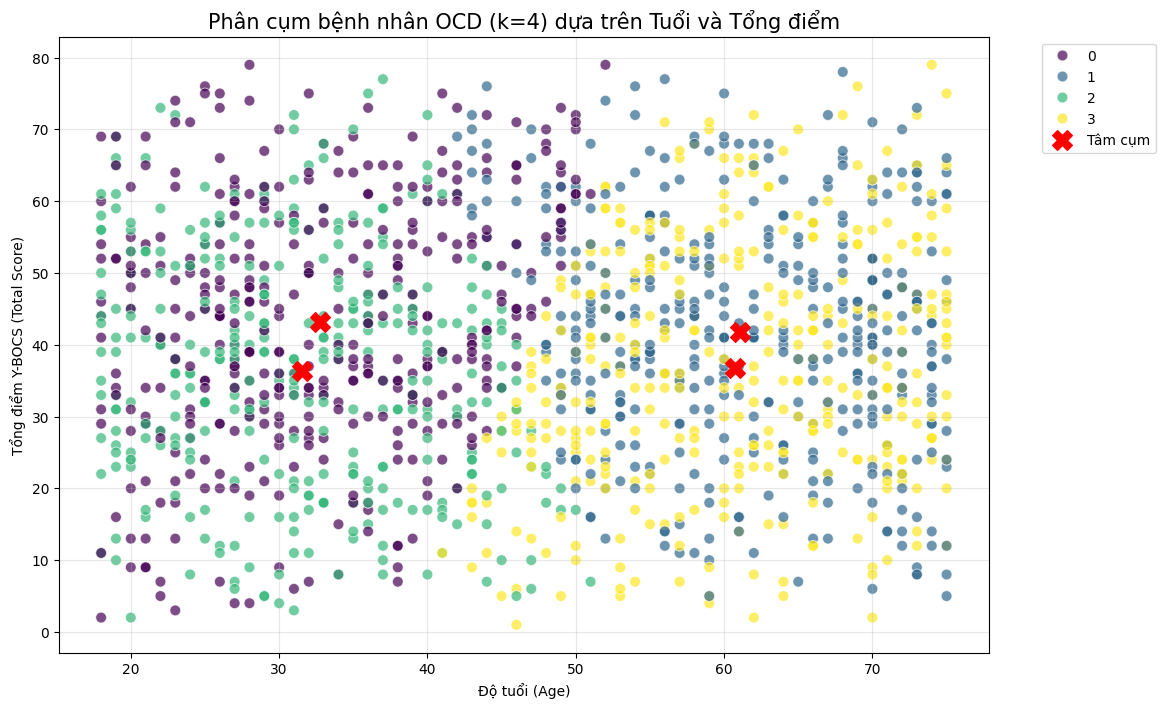

In [6]:
plt.figure(figsize=(12, 8))

# Vẽ Scatter Plot
sns.scatterplot(data=df, x='Age', y='Total_Score', hue='Cluster', 
                palette='viridis', s=60, alpha=0.7, edgecolor='w')

# Vẽ tâm cụm (Centroids)
# Lưu ý: Phải nghịch đảo chuẩn hóa (inverse_transform) để đưa tâm cụm về đơn vị thực tế (Tuổi, Điểm)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Tâm cụm')

plt.title('Phân cụm bệnh nhân OCD (k=4) dựa trên Tuổi và Tổng điểm', fontsize=15)
plt.xlabel('Độ tuổi (Age)')
plt.ylabel('Tổng điểm Y-BOCS (Total Score)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Tính toán các chỉ số trung bình cho từng cụm
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Total_Score': 'mean',
    'Family_History_Bin': 'mean' # Tỷ lệ người có tiền sử gia đình
}).sort_values(by='Total_Score')

print("Hồ sơ đặc trưng của từng cụm bệnh nhân:")
display(cluster_profile)

Hồ sơ đặc trưng của từng cụm bệnh nhân:


,Age,Total_Score,Family_History_Bin
Cluster,,,
2,31.536932,36.411932,1.0
3,60.751412,36.816384,0.0
1,61.073529,41.735294,1.0
0,32.764249,43.090674,0.0


Sự phân hóa nhóm Extreme: Mặc dù tất cả các cụm này đều có điểm trung bình > 31 (thuộc nhóm Extreme), nhưng thuật toán đã tách chúng ra dựa trên yếu tố nhân khẩu học. Điều này chứng minh nghi ngờ của bạn là đúng: nhãn "Extreme" quá rộng và cần được chia nhỏ.

Nhóm nặng nhất (Cluster 0): Thật bất ngờ khi nhóm có điểm số trung bình cao nhất (43.09) lại là những người trẻ (~32 tuổi) và không có tiền sử gia đình. Đây có thể là nhóm gặp các yếu tố môi trường hoặc khởi phát đột ngột rất nặng.

Sự đối lập giữa Cluster 1 và 2: Hai nhóm này đều có 100% tiền sử gia đình, nhưng nhóm lớn tuổi (Cluster 1) có mức độ nghiêm trọng (41.7) cao hơn hẳn nhóm trẻ (36.4). Điều này có thể gợi ý rằng OCD có xu hướng diễn tiến nặng hơn theo thời gian nếu có yếu tố di truyền.

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65798/1380890192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='Duration of Symptoms (months)', palette='Set3')


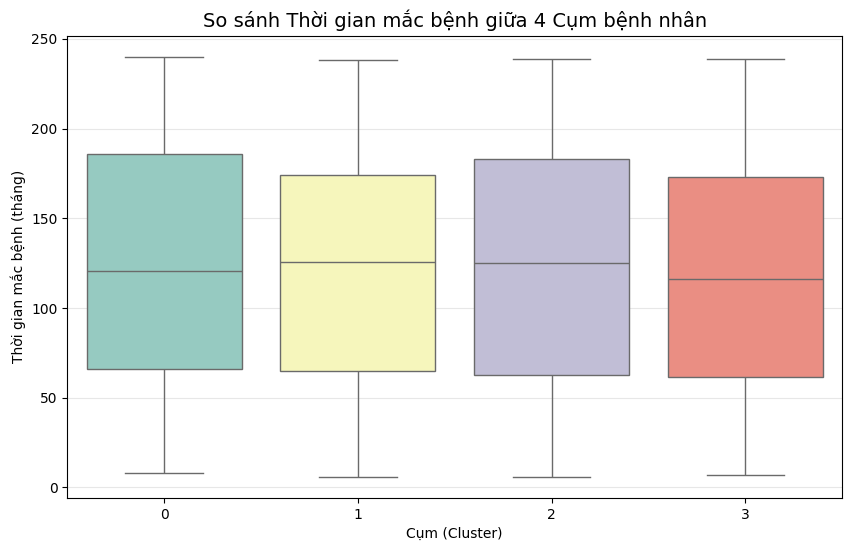

In [8]:
# 1. Vẽ Boxplot so sánh thời gian điều trị giữa các cụm
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cluster', y='Duration of Symptoms (months)', palette='Set3')

plt.title('So sánh Thời gian mắc bệnh giữa 4 Cụm bệnh nhân', fontsize=14)
plt.xlabel('Cụm (Cluster)')
plt.ylabel('Thời gian mắc bệnh (tháng)')
plt.grid(axis='y', alpha=0.3)
plt.show()

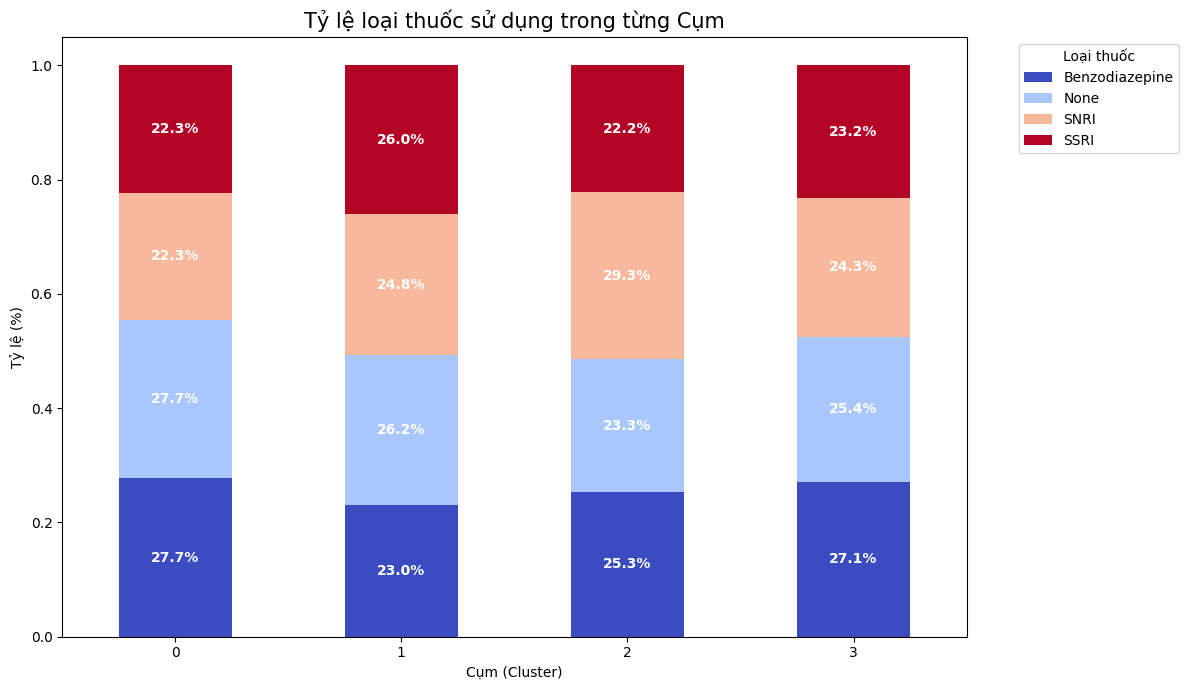

In [9]:
# 2. Tạo bảng tỷ lệ thuốc theo cụm
target_col = 'Medications' if 'Medications' in df.columns else 'Medication'
cluster_med_prop = pd.crosstab(df['Cluster'], df[target_col], normalize='index')

# 3. Vẽ biểu đồ cột chồng
ax = cluster_med_prop.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='coolwarm')

plt.title('Tỷ lệ loại thuốc sử dụng trong từng Cụm', fontsize=15)
plt.xlabel('Cụm (Cluster)')
plt.ylabel('Tỷ lệ (%)')
plt.legend(title='Loại thuốc', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)

# Thêm nhãn %
for p in ax.patches:
    h = p.get_height()
    if h > 0.05:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + h/2, f'{h:.1%}', 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Tỉ lệ thuốc phân bố hầu như gần bằng nhau nên có thể kết luận phác đồ điều trị hiện tại có thể phụ thuộc rất nhiều vào triệu chứng chứ không phải do yếu các yếu tố như di truyền hay nhân khẩu học


Liệu những người bị trầm cảm hoặc lo âu đi kèm có mức độ OCD (Y-BOCS) nặng hơn không?


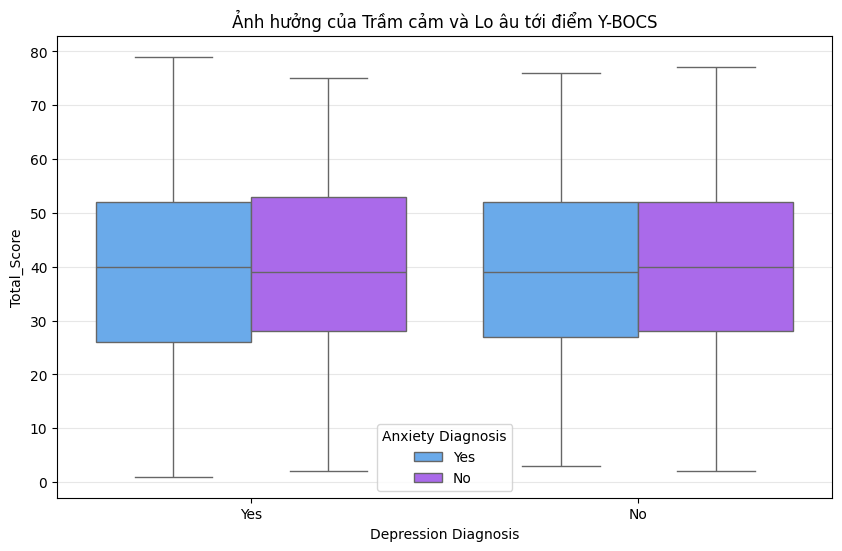

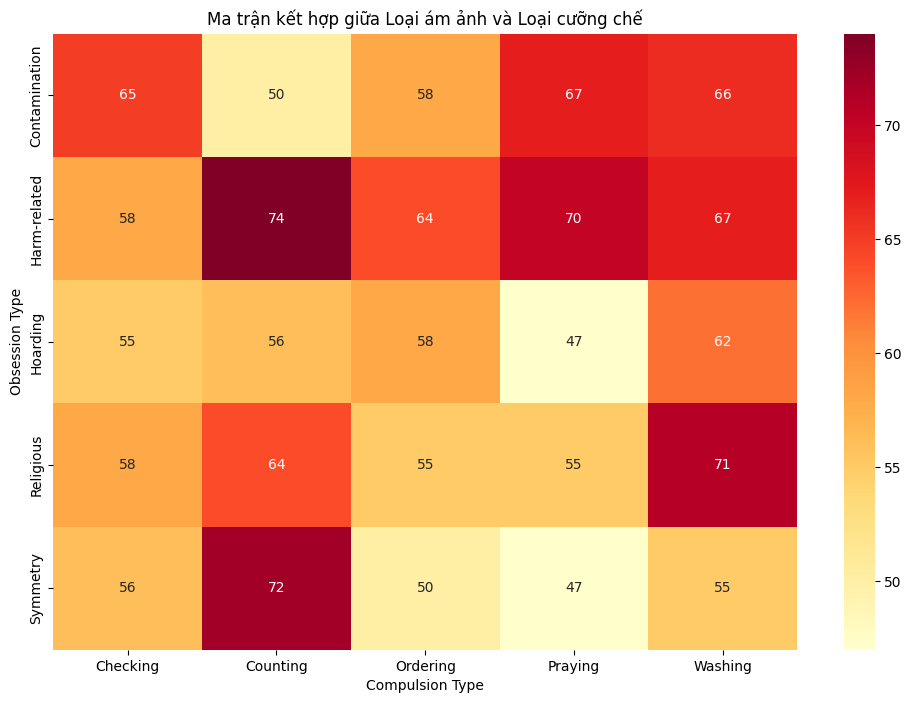

In [10]:
# 1. Kiểm tra ảnh hưởng của Trầm cảm tới mức độ OCD
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Depression Diagnosis', y='Total_Score', hue='Anxiety Diagnosis', palette='cool')
plt.title('Ảnh hưởng của Trầm cảm và Lo âu tới điểm Y-BOCS')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Xem mối quan hệ giữa Loại ám ảnh và Loại cưỡng chế
symptom_map = pd.crosstab(df['Obsession Type'], df['Compulsion Type'])
plt.figure(figsize=(12, 8))
sns.heatmap(symptom_map, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Ma trận kết hợp giữa Loại ám ảnh và Loại cưỡng chế')
plt.show()

Rõ ràng, không có sự khác biệt quá nhiều giữa các nhóm có/không có mắc bệnh trầm cảm/ lo âu khi so sánh liệu những chỉ số đó có ảnh hưởng đến mức độ OCD

Trình độ học vấn có ảnh hưởng đến thời gian bệnh nhân chịu đựng triệu chứng trước khi đi khám không?

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65798/2174757032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Education Level', y='Duration of Symptoms (months)',


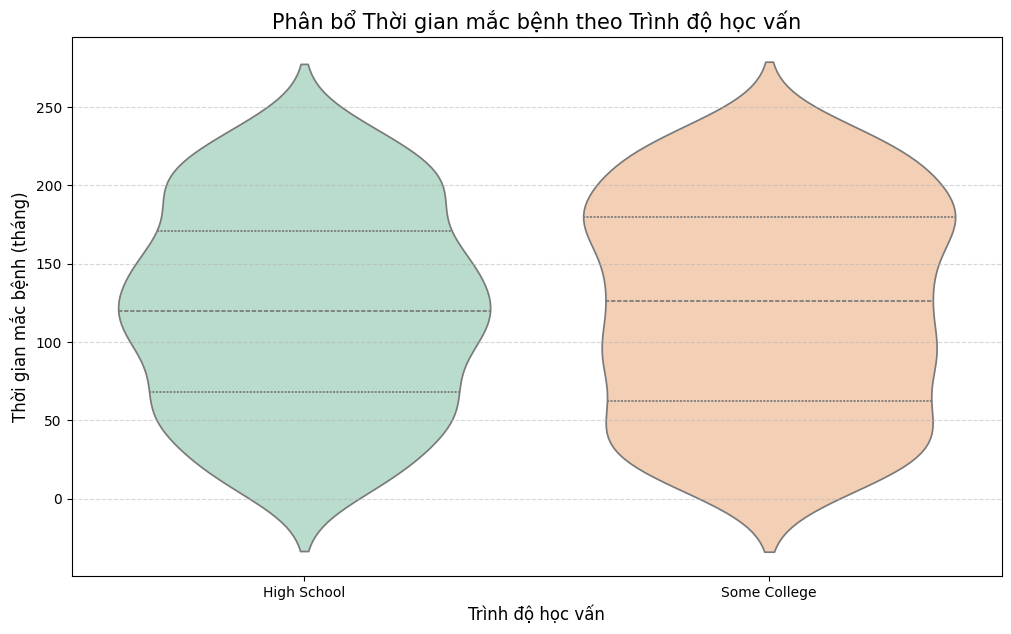

In [12]:
# 1. Sắp xếp thứ tự học vấn theo logic để biểu đồ dễ đọc hơn
edu_order = ['High School', 'Some College']

plt.figure(figsize=(12, 7))

# Vẽ Violin Plot để xem phân phối Duration theo Education Level
sns.violinplot(data=df, x='Education Level', y='Duration of Symptoms (months)', 
               order=edu_order, palette='Pastel2', inner="quartile")

plt.title('Phân bổ Thời gian mắc bệnh theo Trình độ học vấn', fontsize=15)
plt.xlabel('Trình độ học vấn', fontsize=12)
plt.ylabel('Thời gian mắc bệnh (tháng)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

/var/folders/ms/yqt7c73d40xdz8383n8b6rtw0000gp/T/ipykernel_65798/3405038825.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df, x='Marital Status', y='Total_Score',


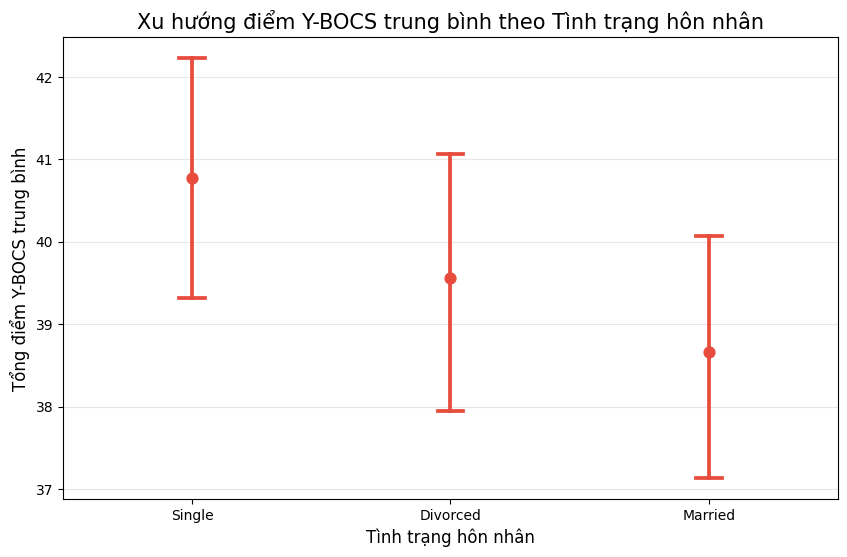

In [13]:
plt.figure(figsize=(10, 6))

# Vẽ Point Plot để xem xu hướng điểm số
sns.pointplot(data=df, x='Marital Status', y='Total_Score', 
              join=False, capsize=.1, color='#E74C3C')

plt.title('Xu hướng điểm Y-BOCS trung bình theo Tình trạng hôn nhân', fontsize=15)
plt.xlabel('Tình trạng hôn nhân', fontsize=12)
plt.ylabel('Tổng điểm Y-BOCS trung bình', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

Kết quả này ủng hộ giả thuyết về Hỗ trợ xã hội (Social Support). Những người đã kết hôn thường có mạng lưới hỗ trợ tinh thần tốt hơn, giúp giảm bớt căng thẳng — một trong những yếu tố kích hoạt mạnh nhất của các triệu chứng OCD.

Để kiểm tra xem, sự khác biệt trên có giá trị thống kê hay không, tôi tiến hành phép thử ANOVA.


In [ ]:
import scipy.stats as stats

single = df[df['Marital Status'] == 'Single']['Total_Score']
married = df[df['Marital Status'] == 'Married']['Total_Score']
divorced = df[df['Marital Status'] == 'Divorced']['Total_Score']

f_stat, p_val = stats.f_oneway(single, married, divorced)

print(f"Giá trị F-statistic: {f_stat:.4f}")
print(f"Giá trị P-value: {p_val:.4f}")

if p_val < 0.05:
    print("=> Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa các nhóm hôn nhân.")
else:
    print("=> Kết luận: Sự khác biệt chưa đủ ý nghĩa thống kê.")

Giá trị F-statistic: 1.9833
Giá trị P-value: 0.1380
=> Kết luận: Sự khác biệt chưa đủ ý nghĩa thống kê.


liệu trình độ học vấn cao có dẫn đến việc độc thân hay không 

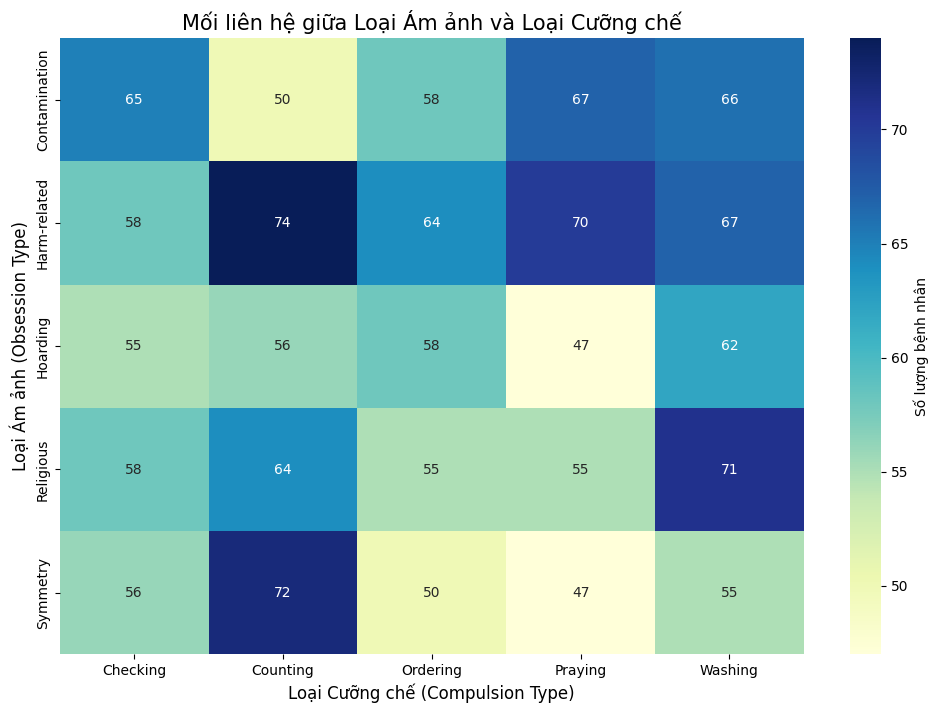

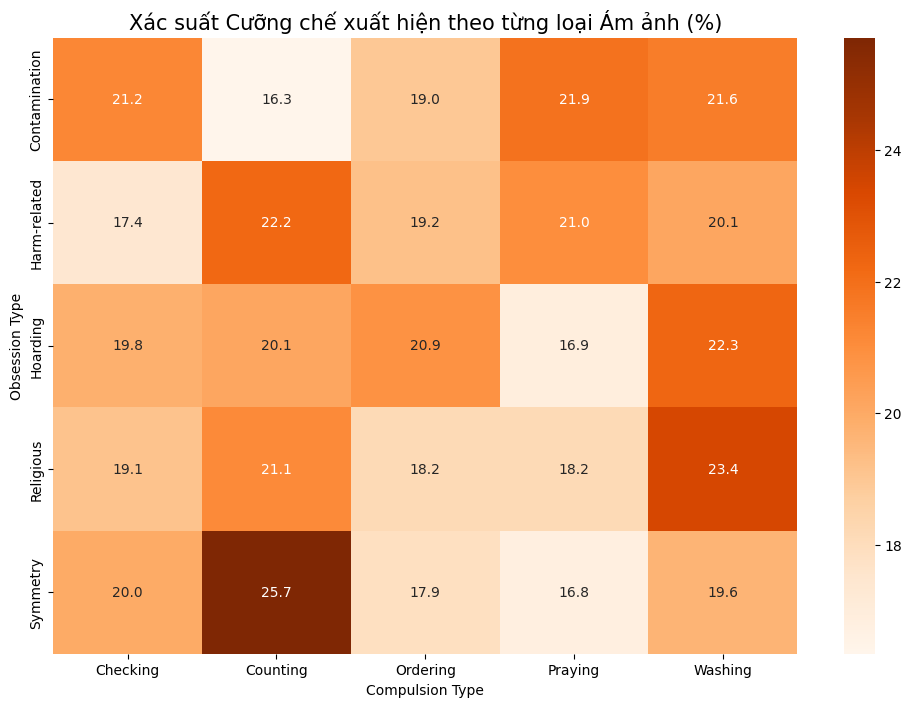

In [15]:
# 1. Tạo bảng chéo tính tần suất xuất hiện
symptom_crosstab = pd.crosstab(df['Obsession Type'], df['Compulsion Type'])

# 2. Vẽ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(symptom_crosstab, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Số lượng bệnh nhân'})

plt.title('Mối liên hệ giữa Loại Ám ảnh và Loại Cưỡng chế', fontsize=15)
plt.xlabel('Loại Cưỡng chế (Compulsion Type)', fontsize=12)
plt.ylabel('Loại Ám ảnh (Obsession Type)', fontsize=12)
plt.show()

# 3. Tính toán tỷ lệ phần trăm theo hàng để xem xác suất điều kiện
# (Ví dụ: Nếu bị ám ảnh 'Sạch sẽ', bao nhiêu % sẽ đi kèm cưỡng chế 'Rửa tay')
symptom_prob = pd.crosstab(df['Obsession Type'], df['Compulsion Type'], normalize='index') * 100
plt.figure(figsize=(12, 8))
sns.heatmap(symptom_prob, annot=True, fmt='.1f', cmap='Oranges')
plt.title('Xác suất Cưỡng chế xuất hiện theo từng loại Ám ảnh (%)', fontsize=15)
plt.show()